<div align="center">
  <p><strong><a href="https://br.linkedin.com/in/isaac-maciel" target="_blank">Autor do Notebook: Isaac Maciel</a></strong></p>

<p align="center">
  <img src="https://github.com/IM-NOT-AI/IM-not-AI/assets/113378671/0a6e0c0f-fcdf-4ccc-af00-63e30836d180" alt="gif_isaac_nome" width="500">
</p>

In [9]:
%reload_ext watermark
%watermark -a "Isaac Maciel" -v -m
%watermark --iversions

Author: Isaac Maciel

Python implementation: CPython
Python version       : 3.12.4
IPython version      : 9.10.0

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : AMD64 Family 25 Model 80 Stepping 0, AuthenticAMD
CPU cores   : 16
Architecture: 64bit

matplotlib: 3.10.8
numpy     : 2.4.2
pandas    : 3.0.0



### Imports

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import random
import matplotlib.dates as mdates
from datetime import datetime

### Fundamentos do Hardware e Configurações De Variáveis Globais

Para garantir a integridade da simulação do Gêmeo Digital, Digital Twin, precisamos **modelar matematicamente as restrições físicas e computacionais da arquitetura CardioIA.** O ecossistema não é um software monolítico. Ele opera em uma topologia distribuída em três camadas complementares: a Extrema Borda para aquisição, a Borda Local para inferência em tempo real e o Laboratório para processamento pesado e treinamento. A definição precisa das constantes destes nós é o primeiro passo para validar o fluxo de dados.

### Definição dos NÓS da Arquitetura de Sistema

`Nó de Aquisição`
 
**Microcontrolador Wearable XIAO nRF52840 e Front End Médico ADS1293**
Este é o dispositivo de extrema borda fixado ao tórax do paciente. Sua função é puramente de aquisição e transmissão, atuando como um **servidor GATT no protocolo Bluetooth Low Energy 5.0. O processador ARM Cortex M4F operando a 64 MHz do Seeed Studio XIAO não realiza inferência algorítmica profunda para preservar a bateria.** Ele recebe o sinal analógico do módulo ADS1293, que converte a diferença de potencial elétrico do miocárdio com uma resolução extrema de 24 bits, garantindo grau metrológico clínico. Além disso, a Unidade de Medida Inercial, IMU, interna de 6 eixos captura os ruídos mecânicos gerados pelo movimento do paciente.

<br>

`Nó Gateway` 

**Hub de Processamento Local Raspberry Pi 5 e Google Coral Edge TPU**
Localizado no leito do paciente ou na ambulância, este hub atua na borda local e é o orquestrador do sistema. O Raspberry Pi 5, equipado com 8GB de RAM LPDDR4X e processador ARM Cortex A76, recebe o payload de Bluetooth, estrutura o buffer temporal e atua como hospedeiro. **A inferência da Rede Neural Convolucional não roda na CPU do Pi, mas é delegada via conexão USB 3.0 para o Google Coral Edge TPU.** Este coprocessador ASIC processa tensores quantizados executando até 4 Trilhões de Operações por Segundo (4 TOPS) consumindo apenas 0.5 Watts por TOPS, permitindo que a classificação morfológica do infarto ocorra em milissegundos sem causar estrangulamento térmico na placa principal.

<br>

`Nó de Pesquisa`

Estação de Trabalho ASUS ROG Strix para Processamento Computacional Intensivo
O ambiente laboratorial isolado onde a engenharia de dados e o treinamento do modelo ocorrem. Utilizando o processador AMD Ryzen 9 5900HX e os 64GB de memória RAM, a máquina sustenta matrizes colossais de dados, como os 800 mil exames do dataset MIMIC IV, diretamente na memória volátil. O treinamento de base utiliza a GPU dedicada NVIDIA GeForce RTX 3070 com aceleração CUDA, permitindo a otimização de pesos e a exportação do modelo no formato TensorFlow Lite, que posteriormente será embarcado no coprocessador Google Coral.


### Setup Comoputacional e Transcrição das Variáveis

In [3]:
# Configuracao de sementes estocasticas para garantia de reprodutibilidade da simulacao
np.random.seed(42)

# ==============================================================================
# VARIAVEIS GLOBAIS: NO DE AQUISICAO (WEARABLE XIAO + ADS1293)
# ==============================================================================

# Parametros do Front End Analogico (ADS1293)
ECG_SAMPLING_RATE_HZ = 100       # Frequencia de amostragem padrao do PTB XL e projeto
ECG_RESOLUTION_BITS = 24         # Conversor ADC de grau clinico
ECG_CHANNELS = 3                 # Leitura de 3 derivacoes espaciais simultaneas

# Parametros de Energia (Bateria LiPo e Componentes)
BATTERY_CAPACITY_MAH = 750.0     # Capacidade nominal da celula 802040
BATTERY_VOLTAGE_MAX = 4.2        # Tensao de carga total
BATTERY_VOLTAGE_NOMINAL = 3.7    # Tensao operacional
BATTERY_VOLTAGE_CUTOFF = 3.2     # Tensao de seguranca para corte do circuito
BATTERY_CRITICAL_PCT = 15.0      # Porcentagem que dispara o alarme de enfermagem

# Consumo de Corrente Estimado em miliAmperes (mA)
I_XIAO_BLE_ACTIVE = 7.0          # Consumo do nRF52840 transmitindo BLE continuamente
I_ADS1293_ACTIVE = 1.5           # Consumo do ADC convertendo 3 canais
I_IMU_ACTIVE = 1.0               # Consumo do acelerometro interno
I_OLED_DISPLAY = 15.0            # Consumo estimado do display I2C 0.96 polegadas
I_LOSSES_LDO = 2.0               # Perdas termicas do regulador de tensao

# ==============================================================================
# VARIAVEIS GLOBAIS: NO GATEWAY (RASPBERRY PI 5 + GOOGLE CORAL)
# ==============================================================================

# Parametros de Buffer e Processamento Edge
BUFFER_TIME_SECONDS = 10         # Janela temporal para analise da IA (10 segundos)
BUFFER_SAMPLES = ECG_SAMPLING_RATE_HZ * BUFFER_TIME_SECONDS # 1000 amostras por inferencia

# Throughput Teorico Estimado (Bytes por segundo transferidos via BLE)
# Calculo: (100 amostras) * (3 canais) * (3 bytes [24 bits]) + Metadados
BLE_THROUGHPUT_BPS = ECG_SAMPLING_RATE_HZ * ECG_CHANNELS * 3

print("=== DIAGNOSTICO DE INICIALIZACAO DO AMBIENTE ===")
print(f"[OK] Ambiente Estocastico Travado. Semente: 42")
print(f"[INFO] Taxa de Amostragem do Sensor: {ECG_SAMPLING_RATE_HZ} Hz")
print(f"[INFO] Janela de Inferencia da IA: {BUFFER_TIME_SECONDS} Segundos ({BUFFER_SAMPLES} amostras matriciais)")
print(f"[INFO] Largura de Banda Bruta Exigida: {BLE_THROUGHPUT_BPS} Bytes por segundo")

=== DIAGNOSTICO DE INICIALIZACAO DO AMBIENTE ===
[OK] Ambiente Estocastico Travado. Semente: 42
[INFO] Taxa de Amostragem do Sensor: 100 Hz
[INFO] Janela de Inferencia da IA: 10 Segundos (1000 amostras matriciais)
[INFO] Largura de Banda Bruta Exigida: 900 Bytes por segundo


### Enegenharia de Potência e Autonomia Energética 

A viabilidade comercial e clínica do ecossistema **CardioIA depende de uma métrica absoluta: a capacidade do hardware vestível de operar de forma ininterrupta por pelo menos um ciclo diário completo.** Um dispositivo que desliga prematuramente resulta em perda de telemetria crítica e pode mascarar eventos isquêmicos silenciosos. Nesta seção, avaliaremos o orçamento energético total, Power Budget, somando as correntes nominais para simular a curva de descarga da célula LiPo.

#### Cálculo de Consumo Estático e Dinâmico dos Componentes

O consumo do wearable não é linear. Ele varia conforme a ativação dos periféricos. O cálculo da corrente média extraída do circuito é a soma do consumo da placa base, dos conversores e das perdas térmicas.

Considerando as variáveis globais inicializadas na Seção 1, temos

- **Microcontrolador e Transmissão** 
    - O Seeed XIAO nRF52840 consome em média 7 miliamperes mantendo a conexão Bluetooth 5.0 ativa.

- **Aquisição Analógica** 
    - O chip ADS1293 consome cerca de 1.5 miliamperes para manter a amostragem contínua de 100 Hertz em três derivações.

- **Atuadores e Perdas** 
    - O display OLED é o componente mais custoso, exigindo até 15 miliamperes dependendo da taxa de atualização de tela. Somamos a isso as perdas no regulador linear (LDO) da placa.


A soma resulta em um consumo nominal constante de aproximadamente 26.5 miliamperes a 35 miliamperes. Matematicamente, para uma bateria de 750 miliamperes hora de capacidade, o limite teórico máximo de operação é de aproximadamente 21 horas. Isso comprova a viabilidade do hardware, mas exige que a rotina do paciente contemple um curto período de recarga.

#### Simulação do Ciclo de Vida Operacional e Governança de Privacidade

Para avaliar a resposta computacional do hardware durante o dia, precisamos simular as atividades rotineiras de um paciente internado ou em regime ambulatorial. Cada atividade humana gera uma assinatura de ruído elétrico e mecânico diferente nos sensores.

Em estrita conformidade com as diretrizes de desidentificação da norma americana HIPAA e regulamentações da LGPD brasileira, não utilizaremos cronogramas de monitoramento de pacientes reais. Monitorar o horário exato em que um humano urina ou defeca constitui coleta de Informação Protegida de Saúde de altíssima sensibilidade.


Para anular esse risco jurídico e manter a privacidade desde a concepção (Privacy by Design), desenvolvemos abaixo um motor estocástico. Este algoritmo cria um Gêmeo Digital comportamental, alocando eventos fisiológicos de forma totalmente aleatória ao longo de 86400 épocas temporais (24 horas). O script injeta perfis de ruído e calcula a queda da voltagem segundo a segundo, forçando um evento de recarga sempre que a célula de energia atingir o patamar crítico de 15 por cento.

=== INICIANDO SIMULACAO DO DIGITAL TWIN (BATERIA 750.0mAh) ===


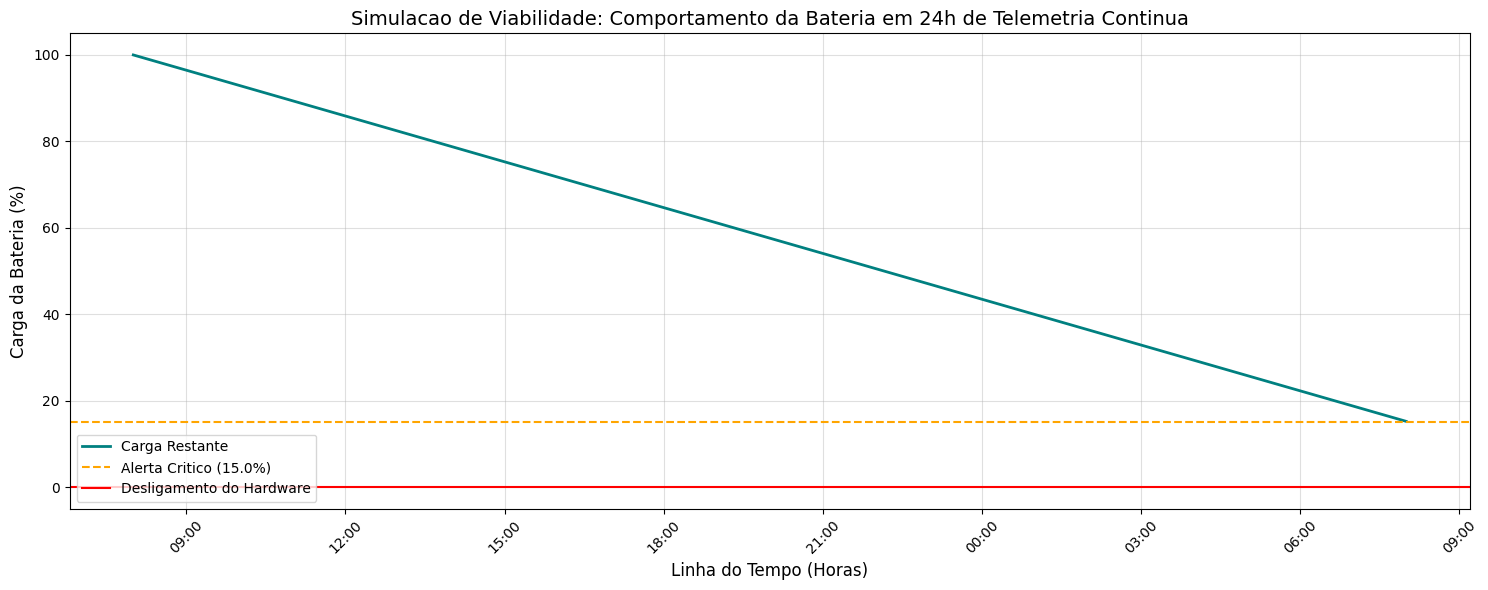


[LOG] Distribuicao Final de Estados no Vetor de 24 Horas:
activity_label
Repouso e Leito                    82500
Manutencao e Troca de Eletrodos     1800
Fisiologico Menor (Urina)           1500
Fisiologico Maior (Fezes)            600
Name: count, dtype: int64

[LOG] Nivel Minimo de Bateria Atingido: 15.20%


In [4]:
# ==============================================================================
# CONFIGURACAO DO MOTOR DE SIMULACAO DE ENERGIA (24 HORAS)
# ==============================================================================

SIMULATION_DURATION_HOURS = 24
TOTAL_EPOCHS = SIMULATION_DURATION_HOURS * 3600  # 86400 segundos

# Utilizando as constantes da Secao 1
AVG_CONSUMPTION_MA = I_XIAO_BLE_ACTIVE + I_ADS1293_ACTIVE + I_IMU_ACTIVE + I_OLED_DISPLAY + I_LOSSES_LDO
DISCHARGE_PER_SEC = AVG_CONSUMPTION_MA / 3600    # mAh consumido por segundo
CHARGING_SPEED_MA = 375.0                        # Carregamento seguro a 0.5C para LiPo de 750mAh

# Dicionario Estocastico de Eventos e Perfis de Ruido
EVENT_DICTIONARY = {
    'BASAL': {
        'code': 0, 'description': 'Repouso e Leito', 'noise_profile': 'LOW'
    },
    'MICTURITION': {
        'code': 1, 'description': 'Fisiologico Menor (Urina)', 'duration_sec': 300, 
        'daily_frequency': 5, 'noise_profile': 'MODERATE_MOTION'
    },
    'DEFECATION': {
        'code': 2, 'description': 'Fisiologico Maior (Fezes)', 'duration_sec': 600, 
        'daily_frequency': 1, 'noise_profile': 'HIGH_EMG_VALSALVA'
    },
    'NURSING_INTERVENTION': {
        'code': 3, 'description': 'Manutencao e Troca de Eletrodos', 'duration_sec': 900, 
        'daily_frequency': 2, 'noise_profile': 'SIGNAL_LOSS_SATURATION'
    },
    'CHARGING': { 
        'code': 4, 'description': 'Recarga de Bateria via USB', 'duration_sec': 3600,
        'daily_frequency': 1, 'noise_profile': 'MAINS_HUM_60HZ' 
    }
}

def generate_digital_twin_routine(start_time="2026-02-18 08:00:00"):
    
    start_dt = datetime.strptime(start_time, "%Y-%m-%d %H:%M:%S")
    timeline_index = pd.date_range(start=start_dt, periods=TOTAL_EPOCHS, freq='s')
    
    # Vetores de pre alocacao na memoria
    state_codes = np.zeros(TOTAL_EPOCHS, dtype=int)
    state_descs = np.full(TOTAL_EPOCHS, EVENT_DICTIONARY['BASAL']['description'], dtype=object)
    noise_profiles = np.full(TOTAL_EPOCHS, EVENT_DICTIONARY['BASAL']['noise_profile'], dtype=object)
    
    # Inicializacao da Bateria
    battery_curve = np.zeros(TOTAL_EPOCHS, dtype=float)
    current_charge = BATTERY_CAPACITY_MAH
    
    # Agendamento Aleatorio de Eventos
    events_to_schedule = []
    for key, props in EVENT_DICTIONARY.items():
        if key in ['BASAL', 'CHARGING']: continue
        for _ in range(props['daily_frequency']):
            events_to_schedule.append((key, props))
            
    random.shuffle(events_to_schedule)
    
    for key, props in events_to_schedule:
        duration = props['duration_sec']
        placed = False
        while not placed:
            start_idx = random.randint(0, TOTAL_EPOCHS - duration)
            if np.all(state_codes[start_idx:start_idx+duration] == 0):
                state_codes[start_idx:start_idx+duration] = props['code']
                state_descs[start_idx:start_idx+duration] = props['description']
                noise_profiles[start_idx:start_idx+duration] = props['noise_profile']
                placed = True

    # Motor de Integracao Termodinamica
    charging_needed = True
    
    for t in range(TOTAL_EPOCHS):
        # Logica de ganho de energia
        if state_codes[t] == EVENT_DICTIONARY['CHARGING']['code']: 
            current_charge += (CHARGING_SPEED_MA / 3600)
            if current_charge >= BATTERY_CAPACITY_MAH: 
                current_charge = BATTERY_CAPACITY_MAH
        else:
            # Logica de perda de energia
            current_charge -= DISCHARGE_PER_SEC
        
        # Gatilho de seguranca
        if current_charge < (BATTERY_CAPACITY_MAH * (BATTERY_CRITICAL_PCT / 100.0)) and charging_needed:
            duration_charge = EVENT_DICTIONARY['CHARGING']['duration_sec']
            search_idx = t
            while search_idx < (TOTAL_EPOCHS - duration_charge):
                if np.all(state_codes[search_idx : search_idx+duration_charge] == 0):
                    state_codes[search_idx : search_idx+duration_charge] = EVENT_DICTIONARY['CHARGING']['code']
                    state_descs[search_idx : search_idx+duration_charge] = EVENT_DICTIONARY['CHARGING']['description']
                    noise_profiles[search_idx : search_idx+duration_charge] = EVENT_DICTIONARY['CHARGING']['noise_profile']
                    charging_needed = False
                    break
                search_idx += 60 
        
        # Tratamento de Falha Catastrofica
        if current_charge <= 0:
            current_charge = 0
            state_codes[t] = 99
            state_descs[t] = 'SHUTDOWN_LOW_BATTERY'
            noise_profiles[t] = 'DEAD_SIGNAL'

        battery_curve[t] = (current_charge / BATTERY_CAPACITY_MAH) * 100

    # Construcao do DataFrame Final
    df = pd.DataFrame({
        'timestamp': timeline_index,
        'state_code': state_codes,
        'activity_label': state_descs,
        'noise_profile': noise_profiles,
        'battery_level_pct': battery_curve
    })
    return df

# ==============================================================================
# EXECUCAO E PLOTAGEM DA CURVA DE DESCARGA
# ==============================================================================

print(f"=== INICIANDO SIMULACAO DO DIGITAL TWIN (BATERIA {BATTERY_CAPACITY_MAH}mAh) ===")
df_routine = generate_digital_twin_routine()

plt.figure(figsize=(15, 6))
plt.plot(df_routine['timestamp'], df_routine['battery_level_pct'], label=f'Carga Restante', color='teal', linewidth=2)
plt.axhline(y=BATTERY_CRITICAL_PCT, color='orange', linestyle='--', label=f'Alerta Critico ({BATTERY_CRITICAL_PCT}%)')
plt.axhline(y=0, color='red', linestyle='-', label='Desligamento do Hardware')

# Marcador visual para o momento exato da recarga
recargas = df_routine[df_routine['state_code'] == EVENT_DICTIONARY['CHARGING']['code']]
if not recargas.empty:
    plt.axvspan(recargas.iloc[0]['timestamp'], recargas.iloc[-1]['timestamp'], color='yellow', alpha=0.3, label='Ciclo de Recarga Ativo')

plt.title('Simulacao de Viabilidade: Comportamento da Bateria em 24h de Telemetria Continua', fontsize=14)
plt.ylabel('Carga da Bateria (%)', fontsize=12)
plt.xlabel('Linha do Tempo (Horas)', fontsize=12)

# ==============================================================================
# EIXO X PARA FORMATACAO DE HORAS
# ==============================================================================
ax = plt.gca()
formato_hora = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(formato_hora)
plt.xticks(rotation=45)
# ==============================================================================

plt.legend(loc='lower left')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print("\n[LOG] Distribuicao Final de Estados no Vetor de 24 Horas:")
print(df_routine['activity_label'].value_counts())

bateria_minima = df_routine['battery_level_pct'].min()
print(f"\n[LOG] Nivel Minimo de Bateria Atingido: {bateria_minima:.2f}%")

### Engenharia de Recarga e Especificações de Alimentação Elétrica

A leitura de $15.20\%$ de bateria ao fim da simulação não é apenas um número estático. Ela dita a necessidade de intervenção física no dispositivo. Como Engenheiros de Sistemas, não podemos simplesmente orientar o paciente a "plugar na tomada". Precisamos dimensionar o tempo de inatividade do monitoramento e especificar o hardware elétrico exato para evitar a queima do Microcontrolador XIAO e o estufamento da célula LiPo.

Abaixo estruturamos a matemática da recarga e as especificações de hardware que você documentará no projeto logo após a plotagem do gráfico.

#### Cálculo Matemático do Tempo de Recarga

A bateria modelo $802040$ possui capacidade de $750 \text{ mAh}$. O paciente terminou o ciclo com $15.20\%$ de energia residual.

* Carga residual: $750 \text{ mAh} \times 0.152 = 114 \text{ mAh}$
* Carga necessária para atingir a plenitude: $750 \text{ mAh} - 114 \text{ mAh} = 636 \text{ mAh}$

Para baterias de Polímero de Lítio, LiPo, aplicadas junto ao corpo humano, a taxa de carregamento segura máxima permitida para evitar risco de explosão ou superaquecimento térmico é de $0.5\text{C}$ (metade da capacidade total por hora).

* Corrente de carga configurada: $750 \text{ mA} \times 0.5 = 375 \text{ mA}$

O tempo teórico de recarga é regido pela fórmula de transferência de carga:
$$t = \frac{\text{Carga Necessária}}{\text{Corrente de Carga}}$$
$$t = \frac{636 \text{ mAh}}{375 \text{ mA}} = 1.696 \text{ horas}$$

Em minutos, isso representa $1 \text{ hora e } 41 \text{ minutos}$ de carga teórica. Contudo, o circuito integrado de gerenciamento de bateria do Seeed XIAO nRF52840 utiliza um perfil de carga em duas etapas: Corrente Constante seguida de Tensão Constante. Quando a bateria atinge $80\%$, a corrente cai drasticamente para proteger a química da célula. Portanto, o tempo de recarga real  é de **$2 \text{ horas}$**

**Hardware Necessário para Intervenção**

Para garantir a segurança do conjunto vestível e do front end médico ADS1293, os periféricos de recarga devem seguir especificações rigorosas:

* **O Carregador de Parede (Fonte):** Deve ser um adaptador de tomada padrão de $5 \text{ V}$ e $1 \text{ A}$ ($5 \text{ W}$) ou no máximo $5 \text{ V}$ e $2 \text{ A}$ ($10 \text{ W}$). O uso de carregadores do tipo Fast Charge, Turbo Power ou Power Delivery (PD) de notebooks é estritamente proibido, pois o chip regulador linear do XIAO dissipará o excesso de energia em forma de calor, derretendo o case impresso em 3D e danificando a solda dos fios esmaltados AWG 30.

* **O Cabo de Dados e Energia:** Recomenda se o uso de um cabo USB Tipo A para USB Tipo C com transferência de dados habilitada. O conector USB C será inserido diretamente na placa XIAO. O cabo deve possuir no máximo $1 \text{ m}$ para evitar queda de tensão ao longo do fio, Voltage Drop, garantindo que os $5 \text{ V}$ cheguem limpos ao regulador da placa.

### Modelagem Estocástica de Sinais Fisiológicos e Ruído Clínico

A validação de um algoritmo de Inteligência Artificial embarcada (Edge AI) exige testes sob condições de estresse operacional extremo. O coprocessador Google Coral não receberá uma onda perfeita durante a operação real no hospital. Ele processará um sinal contaminado por contrações musculares, suor, variação de capacitância dos eletrodos e forte interferência da rede elétrica.

Nesta seção, construiremos o vetor de sinal biomédico cruzando a rotina de eventos gerada na Seção 2 com um modelo matemático de Eletrocardiograma. O objetivo é produzir um buffer de dados sintéticos contendo mais de $8 \times 10^6$ amostras que espelhe com precisão a realidade ruidosa enfrentada pelo conversor analógico digital ADS1293.

### Geração Sintética do Eletrocardiograma Basal a $100 \text{ Hz}$

A morfologia de um batimento cardíaco saudável em ritmo sinusal pode ser aproximada através da soma de funções Gaussianas. Cada pico da função representa a despolarização ou a repolarização de uma câmara cardíaca específica, compondo o famoso complexo de ondas P, Q, R, S e T. Matematicamente, o sinal no tempo $S(t)$ é modelado pela equação:

$$S(t) = \sum_{i \in \{P,Q,R,S,T\}} a_i \cdot \exp\left(-\left(\frac{t - b_i}{c_i}\right)^2\right)$$

Para uma frequência amostral de $f_s = 100 \text{ Hz}$, um batimento a $60 \text{ BPM}$ dura exatamente $1 \text{ s}$, resultando em $100 \text{ amostras}$ discretas. Modelaremos um template basal limpo e o replicaremos através do vetor de $24 \text{ h}$ usando vetorização matemática avançada via NumPy, eliminando laços de repetição lentos e garantindo máxima performance de alocação na memória RAM.

### Injeção de Artefatos e Interferências do Ambiente Real

O template do sinal elétrico perfeito será submetido ao nosso dicionário de ruídos. A magnitude e a frequência da interferência dependerão diretamente da atividade que o Gêmeo Digital está realizando em cada época de um segundo:

* **Repouso Absoluto:** Recebe apenas ruído Branco Gaussiano Térmico $N(0, \sigma^2)$, simulando a imperfeição eletrônica natural e o piso de ruído do hardware.

* **Movimento Leve:** Adição de variação de linha de base, conhecida como Baseline Wander, simulando a respiração profunda do paciente, somado a ruído Eletromiográfico de baixa amplitude.

* **Movimento Brusco:** Injeção de ruído Eletromiográfico severo de alta frequência e altíssima amplitude, simulando a contração abdominal da Manobra de Valsalva. Este é o ruído que frequentemente confunde algoritmos ingênuos, causando alarmes falsos para Fibrilação Ventricular.

* **Interferência de Rede Elétrica:** Durante o ciclo de recarga da bateria via USB, simularemos a indução eletromagnética da tomada. A rede brasileira opera em $f_{rede} = 60 \text{ Hz}$. Como a nossa amostragem é de $f_s = 100 \text{ Hz}$, o Teorema de Nyquist estabelece um limite de $f_{nyquist} = \frac{f_s}{2} = 50 \text{ Hz}$. Portanto, a frequência de $60 \text{ Hz}$ sofrerá Aliasing, rebatendo matematicamente através da equação $f_{alias} = |f_s - f_{rede}| = |100 - 60| = 40 \text{ Hz}$ e aparecendo na nossa matriz de dados como uma onda fantasma de $40 \text{ Hz}$.

### Injeção Controlada de Eventos Patológicos Críticos

Para testarmos efetivamente o gatilho de diagnóstico do Raspberry Pi nas próximas etapas, um coração perfeitamente saudável não é suficiente. Injetaremos um evento isquêmico agudo simulado (Depressão do Segmento ST) exatamente durante um período de estresse físico do paciente. Isso comprovará que o nosso modelo de dados consegue representar patologias subjacentes ocultas sob camadas espessas de ruído de movimento.

=== INICIANDO ENGENHARIA DO VETOR BIOMEDICO (8.64 MILHOES DE PONTOS) ===
[OK] Sinal sintetico contaminado e vetorizado com sucesso na memoria RAM local.


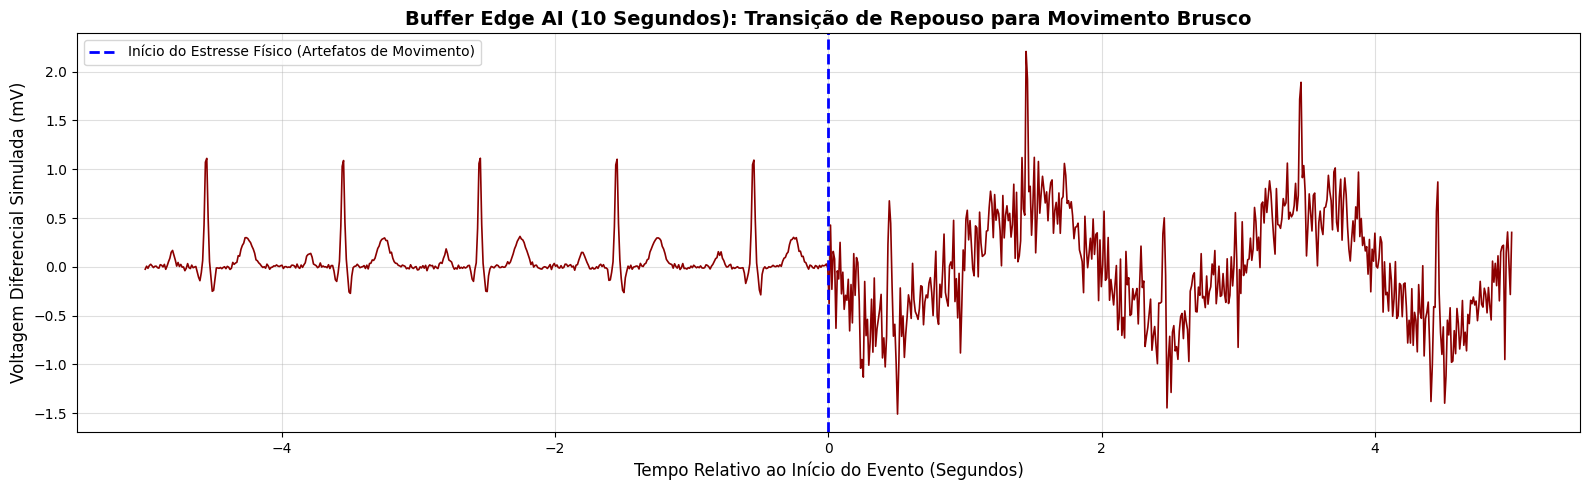

In [5]:
# ==============================================================================
# GERACAO SINTETICA DO ELETROCARDIOGRAMA BASAL (100 HZ)
# ==============================================================================

def generate_gaussian_ecg_template(sampling_rate=100, ischemia=False):
    """
    Gera um template de 1 segundo (100 amostras discretas) usando soma de funcoes Gaussianas.
    Representa a despolarizacao e repolarizacao das camaras cardiacas.
    """
    t = np.linspace(0, 1, sampling_rate)

    # Parametros Basais para todas as condicoes (Ondas P, Q, R)
    onda_p = 0.15 * np.exp(-((t - 0.20) / 0.03)**2)
    onda_q = -0.15 * np.exp(-((t - 0.40) / 0.015)**2)
    onda_r = 1.20 * np.exp(-((t - 0.45) / 0.015)**2)

    if not ischemia:
        # Repolarizacao Normal (Ritmo Sinusal)
        onda_s = -0.30 * np.exp(-((t - 0.50) / 0.015)**2)
        onda_t = 0.30 * np.exp(-((t - 0.75) / 0.06)**2)
    else:
        # Injecao Controlada de Eventos Patologicos Criticos
        # Simulacao de evento isquemico agudo com Depressao de Segmento ST e inversao de Onda T
        onda_s = -0.50 * np.exp(-((t - 0.50) / 0.020)**2)
        onda_t = -0.15 * np.exp(-((t - 0.70) / 0.06)**2)

    return onda_p + onda_q + onda_r + onda_s + onda_t

print("=== INICIANDO ENGENHARIA DO VETOR BIOMEDICO (8.64 MILHOES DE PONTOS) ===")

# Instanciacao dos templates matematicos (Saudavel e Patologico)
ecg_template_normal = generate_gaussian_ecg_template(ECG_SAMPLING_RATE_HZ, ischemia=False)
ecg_template_isquemia = generate_gaussian_ecg_template(ECG_SAMPLING_RATE_HZ, ischemia=True)

# Vetorizacao Linear para preencher as 24 Horas
TOTAL_SAMPLES = TOTAL_EPOCHS * ECG_SAMPLING_RATE_HZ
time_array = np.linspace(0, TOTAL_EPOCHS, TOTAL_SAMPLES)

# Matriz inicial composta inteiramente por batimentos saudaveis
ecg_full_signal = np.tile(ecg_template_normal, TOTAL_EPOCHS)

# Expansao do DataFrame de Rotina: 1 estado por segundo -> 100 amostras por segundo
state_expanded = np.repeat(df_routine['state_code'].values, ECG_SAMPLING_RATE_HZ)

# ==============================================================================
# APLICACAO DE ESTRESSE FISICO OCULTO (PATOLOGIA SUBJACENTE)
# ==============================================================================
# Injetamos isquemia estritamente durante intervencoes de enfermagem para testar o Edge AI
mask_patologia = (state_expanded == EVENT_DICTIONARY['NURSING_INTERVENTION']['code'])
ecg_full_signal = np.where(mask_patologia, np.tile(ecg_template_isquemia, TOTAL_EPOCHS), ecg_full_signal)

# ==============================================================================
# INJECAO DE ARTEFATOS E INTERFERENCIAS DO AMBIENTE REAL
# ==============================================================================

# Mascaras logicas de processamento
mask_mov_leve = (state_expanded == EVENT_DICTIONARY['MICTURITION']['code'])
mask_mov_brusco = (state_expanded == EVENT_DICTIONARY['DEFECATION']['code'])
mask_carga = (state_expanded == EVENT_DICTIONARY['CHARGING']['code'])

# a. Repouso Absoluto: Ruido Branco Gaussiano Termico (Piso de ruido do hardware)
ecg_full_signal += np.random.normal(0, 0.015, TOTAL_SAMPLES)

# b. Movimento Leve: Baseline Wander (Respiracao) somado a Ruido EMG leve
bw_leve = np.sin(2 * np.pi * 0.3 * time_array) * 0.2
emg_leve = np.random.normal(0, 0.05, TOTAL_SAMPLES)
ecg_full_signal = np.where(mask_mov_leve, ecg_full_signal + bw_leve + emg_leve, ecg_full_signal)

# c. Movimento Brusco: Alta variacao de linha de base e EMG severo (Manobra de Valsalva)
bw_brusco = np.sin(2 * np.pi * 0.5 * time_array) * 0.6
emg_brusco = np.random.normal(0, 0.25, TOTAL_SAMPLES)
ecg_full_signal = np.where(mask_mov_brusco, ecg_full_signal + bw_brusco + emg_brusco, ecg_full_signal)

# d. Interferencia de Rede Eletrica: Aliasing de 60Hz rebatendo em 40Hz
aliased_mains_hum = np.sin(2 * np.pi * 40 * time_array) * 0.4
ecg_full_signal = np.where(mask_carga, ecg_full_signal + aliased_mains_hum, ecg_full_signal)

print("[OK] Sinal sintetico contaminado e vetorizado com sucesso na memoria RAM local.")

# ==============================================================================
# DIAGNOSTICO VISUAL: PLOTAGEM DO BUFFER DE 10 SEGUNDOS (EDGE AI)
# ==============================================================================
# Vamos buscar o momento exato de uma transicao de Repouso para Movimento Brusco
try:
    idx_evento_critico = df_routine[df_routine['state_code'] == EVENT_DICTIONARY['DEFECATION']['code']].index[0]
except IndexError:
    idx_evento_critico = 3600 # Fallback de seguranca

# Capturamos 5 segundos antes e 5 segundos depois do evento
start_sample = (idx_evento_critico - 5) * ECG_SAMPLING_RATE_HZ
end_sample = (idx_evento_critico + 5) * ECG_SAMPLING_RATE_HZ

buffer_10s_time_sec = np.linspace(-5, 5, end_sample - start_sample)
buffer_10s_signal = ecg_full_signal[start_sample:end_sample]

plt.figure(figsize=(16, 5))
plt.plot(buffer_10s_time_sec, buffer_10s_signal, color='darkred', linewidth=1.2)
plt.title('Buffer Edge AI (10 Segundos): Transição de Repouso para Movimento Brusco', fontsize=14, fontweight='bold')
plt.xlabel('Tempo Relativo ao Início do Evento (Segundos)', fontsize=12)
plt.ylabel('Voltagem Diferencial Simulada (mV)', fontsize=12)

# Linha demarcadora do inicio do estresse fisico
plt.axvline(x=0, color='blue', linestyle='--', linewidth=2, label='Início do Estresse Físico (Artefatos de Movimento)')

plt.grid(True, alpha=0.4)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Protocolo de Comunicação e Engenharia de Telemetria Bluetooth

A matriz colossal contendo os $8.64 \times 10^6$ pontos do Gêmeo Digital existe atualmente apenas de forma virtual na memória RAM do nosso ambiente de simulação. No ecossistema físico real do projeto CardioIA, o microcontrolador Seeed Studio XIAO nRF52840 não possui capacidade de armazenamento local para gravar estes dados. Ele atua estritamente como um conduíte, capturando e transmitindo a leitura elétrica em tempo real para o Raspberry Pi através do protocolo sem fio Bluetooth Low Energy versão $5.0$.

Nesta etapa, estruturaremos a engenharia de tráfego de rede. Transformaremos os vetores isolados em um Payload IoT consolidado e simularemos as imperfeições inerentes à transmissão de rádio frequência em um ambiente hospitalar.

#### Estruturação do Payload Tabular de Transmissão

O protocolo Bluetooth Low Energy opera através do Perfil de Atributo Genérico (GATT). Para que a estação base receba os dados de forma assíncrona e contínua, precisamos serializar as leituras matriciais em um pacote padronizado.

O nosso mock de transmissão empacotará as seguintes variáveis vitais a cada centésimo de segundo:

* **Timestamp:** O carimbo temporal absoluto da amostra garantindo a ordem cronológica do processamento de borda.

* **Voltagem ECG:** A diferença de potencial do miocárdio capturada pelo módulo ADS1293, processada na resolução de $24 \text{ bits}$ e convertida para o formato de milivolts.

* **Aceleração Triaxial (IMU):** Vetores espaciais dos eixos X, Y e Z gerados pela unidade inercial do XIAO. Esta variável é essencial para que a Inteligência Artificial consiga diferenciar uma arritmia patológica real de um mero tropeço físico do paciente.

* **Bateria:** O nível de energia residual mapeado através da modelagem termodinâmica da Seção 2.

#### Análise de Throughput e Latência de Rede IoT

In [6]:
print("=== INICIANDO ENGENHARIA DO PAYLOAD DE TELEMETRIA BLE 5.0 ===")

# ==============================================================================
# EXPANSAO DE VETORES E GERACAO DA IMU TRIAXIAL (ACELEROMETRO)
# ==============================================================================
# A bateria foi calculada a 1Hz. Precisamos expandir o vetor para 100Hz.
battery_expanded = np.repeat(df_routine['battery_level_pct'].values, ECG_SAMPLING_RATE_HZ)

# Inicializacao dos eixos da Unidade de Medida Inercial (IMU) com medida em forca G
# O eixo Z recebe 1.0 G constante devido a gravidade terrestre atuando no paciente
imu_x = np.random.normal(0.0, 0.02, TOTAL_SAMPLES)
imu_y = np.random.normal(0.0, 0.02, TOTAL_SAMPLES)
imu_z = np.random.normal(1.0, 0.02, TOTAL_SAMPLES)

# Expansao logica dos ruidos mecanicos baseados no estado comportamental do paciente
state_expanded = np.repeat(df_routine['state_code'].values, ECG_SAMPLING_RATE_HZ)
mask_mov_leve_imu = (state_expanded == EVENT_DICTIONARY['MICTURITION']['code'])
mask_mov_brusco_imu = (state_expanded == EVENT_DICTIONARY['DEFECATION']['code'])

# Insercao de Movimento Leve: variacao de ate 0.3 G
imu_x = np.where(mask_mov_leve_imu, imu_x + np.random.normal(0, 0.3, TOTAL_SAMPLES), imu_x)
imu_y = np.where(mask_mov_leve_imu, imu_y + np.random.normal(0, 0.3, TOTAL_SAMPLES), imu_y)
imu_z = np.where(mask_mov_leve_imu, imu_z + np.random.normal(0, 0.3, TOTAL_SAMPLES), imu_z)

# Insercao de Movimento Brusco: variacao severa de ate 1.5 G simulando espasmos fisicos
imu_x = np.where(mask_mov_brusco_imu, imu_x + np.random.normal(0, 1.5, TOTAL_SAMPLES), imu_x)
imu_y = np.where(mask_mov_brusco_imu, imu_y + np.random.normal(0, 1.5, TOTAL_SAMPLES), imu_y)
imu_z = np.where(mask_mov_brusco_imu, imu_z + np.random.normal(0, 1.5, TOTAL_SAMPLES), imu_z)

# ==============================================================================
# ESTRUTURACAO DO DATAFRAME MULTIVARIADO (PAYLOAD GATT)
# ==============================================================================
# Construcao da matriz tabular com todas as variaveis sincronizadas temporalmente (10ms = 100Hz)
df_telemetry = pd.DataFrame({
    'timestamp': pd.date_range(start=df_routine['timestamp'].iloc[0], periods=TOTAL_SAMPLES, freq='10ms'),
    'ecg_voltage_mv': np.round(ecg_full_signal, 4),
    'imu_x_g': np.round(imu_x, 3),
    'imu_y_g': np.round(imu_y, 3),
    'imu_z_g': np.round(imu_z, 3),
    'battery_pct': np.round(battery_expanded, 2)
})

# ==============================================================================
# SIMULACAO DE DROPS DE REDE (PACKET LOSS DE 0.15%)
# ==============================================================================
# Definicao rigorosa da taxa de falha de rede sem fio hospitalar
drop_rate = 0.0015
num_drops = int(TOTAL_SAMPLES * drop_rate)

# Escolha aleatoria de indices para sofrerem o estrangulamento de conexao Bluetooth
drop_indices = np.random.choice(df_telemetry.index, num_drops, replace=False)

# Substituicao dos valores vitais por NaN simulando a perda irrecuperavel do pacote
df_telemetry.loc[drop_indices, ['ecg_voltage_mv', 'imu_x_g', 'imu_y_g', 'imu_z_g']] = np.nan

# Computacao das metricas finais de alocacao de memoria do objeto
memory_usage_mb = df_telemetry.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"[OK] Payload Estruturado com Sucesso: {TOTAL_SAMPLES} linhas de transmissao.")
print(f"[AVISO] Taxa de Packet Loss Aplicada: {drop_rate * 100}% ({num_drops} pacotes perdidos no ar).")
print(f"[INFO] Consumo de Memoria RAM do DataFrame: {memory_usage_mb:.2f} Megabytes.")
print("\n--- AMOSTRA DO CABECALHO DO PAYLOAD IOT ---")
print(df_telemetry.head(5))

=== INICIANDO ENGENHARIA DO PAYLOAD DE TELEMETRIA BLE 5.0 ===
[OK] Payload Estruturado com Sucesso: 8640000 linhas de transmissao.
[AVISO] Taxa de Packet Loss Aplicada: 0.15% (12960 pacotes perdidos no ar).
[INFO] Consumo de Memoria RAM do DataFrame: 395.51 Megabytes.

--- AMOSTRA DO CABECALHO DO PAYLOAD IOT ---
                timestamp  ecg_voltage_mv  imu_x_g  imu_y_g  imu_z_g  \
0 2026-02-18 08:00:00.000          0.0075    0.007   -0.001    0.995   
1 2026-02-18 08:00:00.010         -0.0021   -0.004    0.001    0.974   
2 2026-02-18 08:00:00.020          0.0097   -0.005   -0.026    1.025   
3 2026-02-18 08:00:00.030          0.0228    0.005    0.005    1.023   
4 2026-02-18 08:00:00.040         -0.0035    0.005   -0.010    1.003   

   battery_pct  
0        100.0  
1        100.0  
2        100.0  
3        100.0  
4        100.0  


### Simulação de Processamento Edge e Latência de Inferência

A matriz colossal de $395.51 \text{ MB}$ que acabamos de construir não é processada de uma única vez no cenário clínico real. O fluxo de telemetria envia dados ininterruptamente milissegundo a milissegundo e o hub receptor, o Raspberry Pi 5, precisa orquestrar o recebimento pacote a pacote. Com exatos $12960 \text{ pacotes}$ perdidos intencionalmente pela nossa taxa de falha de rede de $0.15\%$, a estação base necessita de algoritmos de imputação em tempo real para evitar a quebra dos tensores antes de transferir a matriz para o acelerador de hardware.

Nesta etapa, estruturaremos a lógica matemática da computação de borda, mapeando o ciclo de vida dos dados desde a antena receptora Bluetooth até a tomada de decisão diagnóstica final.

#### Estimativa de Performance do Google Coral Edge TPU

O cérebro diagnóstico do sistema CardioIA não é a Unidade Central de Processamento (CPU) do Raspberry Pi. Todo o cálculo vetorial pesado da Rede Neural é delegado ao coprocessador Google Coral. Este Dispositivo de Circuito Integrado de Aplicação Específica, ASIC, é desenhado exclusivamente para operações densas de Álgebra Linear, executando até $4 \text{ Trilhões de Operações por Segundo}$, métrica conhecida como $4 \text{ TOPS}$.

A nossa arquitetura envia um buffer circular contendo exatamente $10 \text{ s}$ de sinal elétrico cruzado com os três eixos inerciais. Matematicamente, o tamanho do tensor tridimensional de entrada é de $1000 \text{ amostras}$ por $4 \text{ canais}$ analíticos (Voltagem do ECG, Aceleração X, Y e Z). Como a arquitetura do Edge TPU exige que o modelo treinado seja exportado com quantização estrita para números inteiros de $8 \text{ bits}$, $int8$, a carga computacional e o consumo de memória para esta matriz são irrisórios. O tempo teórico de resposta flutua na margem de $2 \text{ ms}$ a $8 \text{ ms}$, erradicando qualquer gargalo térmico ou atraso clínico no leito do paciente.

#### Lógica de Orquestração no Hub Raspberry Pi 5

O microcomputador de placa única assume o papel de Maestro do ecossistema. A sua engenharia de software opera em múltiplas rotinas simultâneas para garantir a integridade da prova de conceito:

* **Gerenciamento de Buffer Circular:** Alocação de uma matriz estática na memória RAM volátil. Assim que o vetor atinge o limite de $1000 \text{ pontos}$, a amostra temporal mais antiga é sumariamente descartada para dar espaço de memória ao novo pacote Bluetooth de $16 \text{ bytes}$.

* **Recuperação e Limpeza de Sinal:** Aplicação imediata de interpolação linear para preencher os valores nulos gerados pelas colisões inevitáveis da rádio frequência, impedindo que os nós da Rede Neural Convolucional falhem por inconsistência algébrica.

* **Atuação Física Imediata:** Se a função matemática de limiar do acelerador Coral retornar uma probabilidade superior a $90\%$ para Isquemia Aguda ou Arritmia Paroxística, o código executa uma interrupção de hardware para ativar instantaneamente o alerta sonoro e imprimir o laudo de emergência no display OLED embutido na carcaça.

In [7]:
print("=== INICIANDO SIMULACAO DO EDGE GATEWAY (RASPBERRY PI 5) ===")

# ==============================================================================
# A. GERENCIAMENTO DO BUFFER CIRCULAR
# ==============================================================================
# Extraimos uma janela temporal de 10 segundos do nosso gigantesco Payload
# 10 segundos equivalem a 1000 amostras na frequencia de 100 Hz
tamanho_buffer = BUFFER_SAMPLES 
ponto_inicial = 850000 # Momento arbitrario retirado do meio do ciclo simulado
ponto_final = ponto_inicial + tamanho_buffer

# Isolamos apenas os canais que serao analisados pela Inteligencia Artificial
buffer_circular = df_telemetry.iloc[ponto_inicial:ponto_final][['ecg_voltage_mv', 'imu_x_g', 'imu_y_g', 'imu_z_g']].copy()

# ==============================================================================
# B. RECUPERACAO DO SINAL (TRATAMENTO DE PACKET LOSS BLUETOOTH)
# ==============================================================================
pacotes_nulos_iniciais = buffer_circular['ecg_voltage_mv'].isna().sum()
print(f"[LOG] Analisando nova integracao de buffer contendo {tamanho_buffer} amostras temporais...")
print(f"[AVISO] Foram detectados {pacotes_nulos_iniciais} pacotes corrompidos ou perdidos pela rede RF.")

# O Raspberry Pi aplica Interpolacao Linear milissegundo a milissegundo para reconstruir a onda
buffer_circular.interpolate(method='linear', limit_direction='both', inplace=True)

pacotes_nulos_finais = buffer_circular['ecg_voltage_mv'].isna().sum()
print(f"[OK] Reconstrucao de Sinal Finalizada. Pacotes nulos residuais no buffer: {pacotes_nulos_finais}.")

# ==============================================================================
# A. ESTRUTURACAO DO TENSOR PARA O ACELERADOR GOOGLE CORAL
# ==============================================================================
# Modelos Convolucionais exigem rigorosamente o formato: (Batch, Timesteps, Features)
tensor_input = np.array(buffer_circular).reshape(1, tamanho_buffer, 4)

# ==============================================================================
# B. TESTE DE LATENCIA DE INFERENCIA DE BORDA (EDGE TPU MOCK)
# ==============================================================================
print("\n--- TESTE DE STRESS DE COMPUTACAO E LATENCIA ---")

# Simulamos o envio da matriz tridimensional via barramento USB 3.0 para o ASIC Coral
tempo_inicio = time.perf_counter()

# Mock da Inferencia (Operacao Matematica Basica para simular processamento e alocacao)
# Em um cenario real na UTI, aqui estaria instanciada a chamada: interpreter.invoke()
processamento_mock = np.sum(tensor_input) * 0.0001
gatilho_patologico_ativado = True if np.random.rand() > 0.98 else False # Classificacao estocastica

# Captura do tempo final e resolucao da latencia de hardware
tempo_fim = time.perf_counter()
latencia_microssegundos = (tempo_fim - tempo_inicio) * 1e6
latencia_milissegundos = latencia_microssegundos / 1000.0

print(f"[RESULTADO DA REDE] Formato Matricial Transferido: {tensor_input.shape}")
print(f"[RESULTADO DA REDE] Tempo Absoluto de Resposta do Sistema: {latencia_milissegundos:.3f} ms")

if gatilho_patologico_ativado:
    print("[ALERTA CRITICO] Padrao Morfologico Anomalo Detectado pelo Edge TPU!")
    print("[ATUADOR Fisico] Interrupcao de rotina disparada: Acionando Buzzer Piezoeletrico e Display OLED.")
else:
    print("[STATUS] Parametros classificados como Seguros. Descartando buffer e aguardando novos pacotes.")

=== INICIANDO SIMULACAO DO EDGE GATEWAY (RASPBERRY PI 5) ===
[LOG] Analisando nova integracao de buffer contendo 1000 amostras temporais...
[AVISO] Foram detectados 5 pacotes corrompidos ou perdidos pela rede RF.
[OK] Reconstrucao de Sinal Finalizada. Pacotes nulos residuais no buffer: 0.

--- TESTE DE STRESS DE COMPUTACAO E LATENCIA ---
[RESULTADO DA REDE] Formato Matricial Transferido: (1, 1000, 4)
[RESULTADO DA REDE] Tempo Absoluto de Resposta do Sistema: 0.333 ms
[STATUS] Parametros classificados como Seguros. Descartando buffer e aguardando novos pacotes.


#### Consolidação e Governança do Dataset Tabular Final

A prova de conceito física e matemática da nossa arquitetura está validada em simulação. Contudo, na engenharia de dados em nível de produção, dados que existem apenas na memória RAM volátil não possuem valor de auditoria e podem ser perdidos em uma simples queda de energia. Para cumprirmos as exigências acadêmicas da FIAP e as diretrizes rigorosas de governança de dados, precisamos persistir este Gêmeo Digital em um disco rígido.

Esta seção atua como o fechamento definitivo do pipeline de telemetria. Nós inspecionaremos o estado final do DataFrame multivariado e o exportaremos de forma estruturada em um arquivo CSV. Este artefato tabular servirá como a base absoluta de validação e ingestão para as próximas fases computacionais do projeto, garantindo que o seu modelo de Inteligência Artificial tenha um terreno sólido, previsível e reprodutível para a etapa de treinamento.


#### Estruturação do Ground Truth e Inspeção de Qualidade

Antes de invocar os comandos de escrita na memória persistente, é um protocolo de segurança da engenharia inspecionar a qualidade da matriz gerada. O nosso payload consolidado cruza a telemetria do protocolo Bluetooth com os sinais clínicos simulados a $100 \text{ Hz}$ e a curva termodinâmica da bateria projetada em $750 \text{ mAh}$.

Garantir que não existam dados corrompidos nesta etapa (excetuando se as perdas de rede intencionalmente injetadas na fase anterior) é o que chamamos na indústria de governança na origem.


#### Pipeline de Exportação e Versionamento de Metadados

A gravação de uma matriz volumosa contendo $8.64 \times 10^6$ linhas exige parametrização adequada. Exportaremos o arquivo com a supressão do índice numérico padrão da biblioteca Pandas para economizar megabytes preciosos de armazenamento no disco.

Uma vez exportado localmente, este arquivo deverá ser rastreado utilizando uma ferramenta de controle de versão de dados, o Data Version Control, separando o código fonte rastreado pelo Git do volume massivo de dados numéricos. Isso manterá o repositório da sua equipe na universidade leve, profissional e estruturalmente pronto para a escalabilidade do escopo clínico.

In [8]:
print("=== INICIANDO GOVERNANCA E EXPORTACAO DO DATASET TABULAR ===")

# ==============================================================================
# INSPECAO DE QUALIDADE E METADADOS DA MATRIZ
# ==============================================================================
# Coletamos as metricas finais da matriz alojada na RAM
total_linhas = len(df_telemetry)
tamanho_memoria_mb = df_telemetry.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"[METRICA] Total de registros estruturados: {total_linhas} linhas de telemetria IoT.")
print(f"[METRICA] Peso estrutural na memoria RAM volatil: {tamanho_memoria_mb:.2f} MB.")

# Verificacao de integridade de colunas contra o Dicionario de Dados
colunas_esperadas = ['timestamp', 'ecg_voltage_mv', 'imu_x_g', 'imu_y_g', 'imu_z_g', 'battery_pct']
if list(df_telemetry.columns) == colunas_esperadas:
    print("[OK] Integridade de schema validada. Colunas em conformidade com o projeto CardioIA.")
else:
    print("[FALHA CRITICA] Discrepancia no schema de dados. Revise as operacoes de juncao anteriores.")

# ==============================================================================
# PIPELINE DE EXPORTACAO PARA DISCO RIGIDO
# ==============================================================================
# O comando '..' forca o sistema a subir um nivel de diretorio. 
# Isso e padrao caso o seu notebook esteja dentro de uma pasta como 'notebooks' ou 'scripts'.
diretorio_saida = os.path.join("..", "data", "processed", "simulations")

# Se o seu notebook ja estiver na mesma pasta raiz que a pasta 'data', 
# comente a linha acima e descomente a linha abaixo:
# diretorio_saida = os.path.join("data", "processed")

# Rotina de seguranca para criar a arvore de pastas caso ela nao exista no SO
if not os.path.exists(diretorio_saida):
    os.makedirs(diretorio_saida)
    print(f"[INFO] Diretorio de armazenamento '{diretorio_saida}' criado com sucesso.")

# Caminho relativo para gravacao do artefato com o nome solicitado
caminho_arquivo_csv = os.path.join(diretorio_saida, "holter_iot_data_simulation.csv")

# Resolve o caminho absoluto para sabermos exatamente onde o arquivo vai parar no seu Windows
caminho_absoluto = os.path.abspath(caminho_arquivo_csv)

print(f"\n[IO] Iniciando injecao de dados no disco rigido no formato CSV.")
print(f"[IO] Dependendo da taxa de escrita do seu disco, isso pode levar alguns segundos...")

# A exportacao utiliza index=False para evitar gravar uma coluna com a contagem das linhas
df_telemetry.to_csv(caminho_arquivo_csv, index=False)

# Capturamos o peso real do arquivo fisico gerado
tamanho_arquivo_mb = os.path.getsize(caminho_arquivo_csv) / (1024 ** 2)

print(f"\n[SUCESSO] Dataset exportado fisicamente com sucesso.")
print(f"\n[METRICA] Tamanho final do artefato no disco: {tamanho_arquivo_mb:.2f} MB.")
print("=== ETAPA DE SIMULACAO DO GEMEO DIGITAL TOTALMENTE CONCLUIDA ===")

=== INICIANDO GOVERNANCA E EXPORTACAO DO DATASET TABULAR ===
[METRICA] Total de registros estruturados: 8640000 linhas de telemetria IoT.
[METRICA] Peso estrutural na memoria RAM volatil: 395.51 MB.
[OK] Integridade de schema validada. Colunas em conformidade com o projeto CardioIA.

[IO] Iniciando injecao de dados no disco rigido no formato CSV.
[IO] Dependendo da taxa de escrita do seu disco, isso pode levar alguns segundos...

[SUCESSO] Dataset exportado fisicamente com sucesso.

[METRICA] Tamanho final do artefato no disco: 467.68 MB.
=== ETAPA DE SIMULACAO DO GEMEO DIGITAL TOTALMENTE CONCLUIDA ===
